In [2]:
import torch
import torchvision
import matplotlib.pyplot as plt
import torch.nn as nn
import time

In [3]:
from torchvision import datasets, transforms

In [4]:
from torch.utils.data import DataLoader

In [5]:
transform = transforms.ToTensor()

In [6]:
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

5
torch.Size([1, 28, 28])


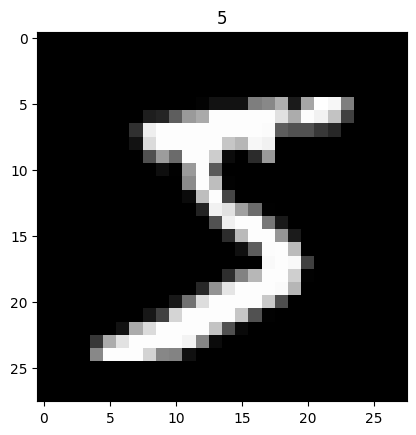

In [7]:
image, label = train_dataset[0]

print(label)
print(image.shape)

plt.imshow(image.squeeze(), cmap='gray')
plt.title(label)
plt.show()

In [8]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True
)

In [9]:
images, labels = next(iter(train_loader))

In [10]:
print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [11]:
class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.model = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):

        x = self.flatten(x)

        output = self.model(x)

        return output

In [12]:
model = NeuralNetwork()

print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [13]:
outputs = model(images)

print(outputs.shape)

torch.Size([64, 10])


In [14]:
loss_function = nn.CrossEntropyLoss()

In [15]:
loss = loss_function(outputs, labels)

In [16]:
print(loss)

tensor(2.3065, grad_fn=<NllLossBackward0>)


In [17]:
optimiser = torch.optim.Adam(model.parameters(), lr=0.001)

In [18]:
epoches = 5

epoch_losses = []

start_time = time.time()

for epoch in range(epoches):

    running_loss = 0

    for images, labels in train_loader:

        outputs = model(images)

        loss = loss_function(outputs, labels)

        optimiser.zero_grad()

        loss.backward()

        optimiser.step()

        running_loss += loss.item()

    average_loss = running_loss / len(train_loader)

    epoch_losses.append(average_loss)

    print(f"Epoch [{epoch+1}/{epoches}], Loss: {loss.item():.4f}")

end_time = time.time()

print(f"Training Time: {end_time - start_time} seconds")

Epoch [1/5], Loss: 0.0930
Epoch [2/5], Loss: 0.0407
Epoch [3/5], Loss: 0.0814
Epoch [4/5], Loss: 0.0251
Epoch [5/5], Loss: 0.0601
Training Time: 27.347391843795776 seconds


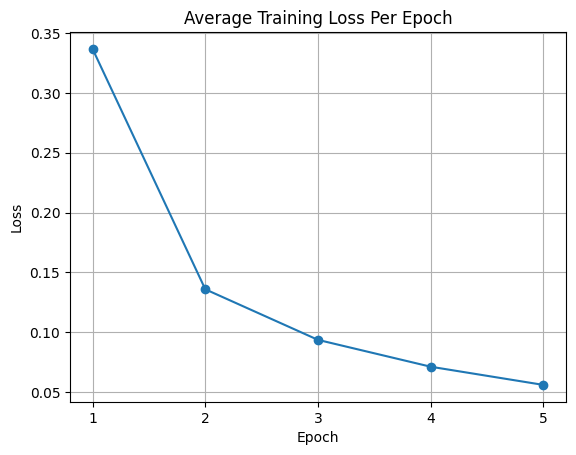

In [19]:
plt.plot(range(1, epoches + 1), epoch_losses, marker='o')

plt.title("Average Training Loss Per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.xticks(range(1, epoches + 1))

plt.grid(True)

plt.show()

In [20]:
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [21]:
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=64,
    shuffle=False
)

In [22]:
start_time = time.time()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        total += labels.size(0)

        correct += (predictions == labels).sum().item()

accuracy = (correct / total) * 100

print(f"Accuracy: {accuracy:.2f}%")

end_time = time.time()

print(f"Time Taken: {end_time - start_time} seconds")

Accuracy: 97.79%
Time Taken: 0.7359108924865723 seconds


In [23]:
images, labels = next(iter(test_loader))

In [24]:
outputs = model(images)

predictions = torch.argmax(outputs, dim=1)

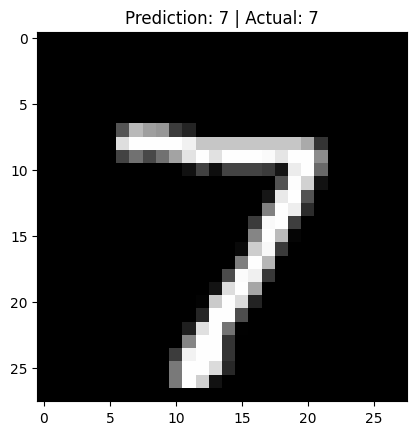

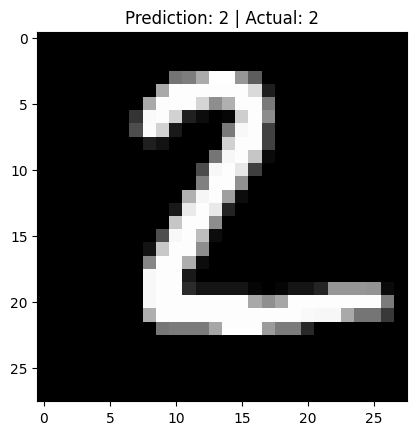

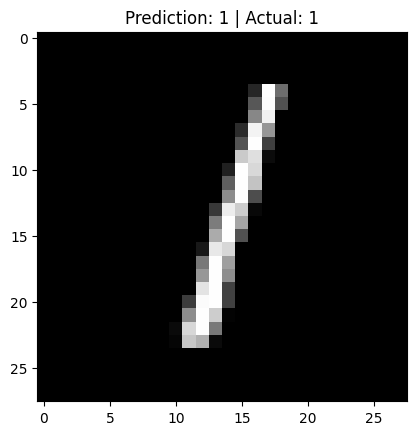

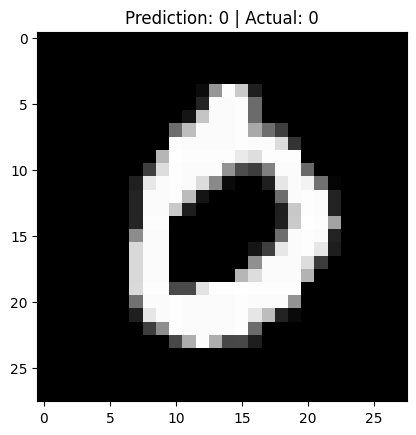

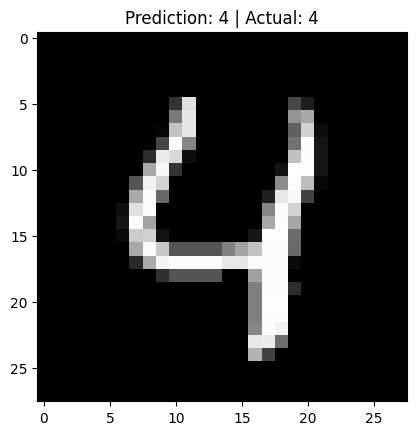

In [25]:
for i in range(5):

    plt.imshow(images[i].squeeze(), cmap='gray')

    plt.title(f"Prediction: {predictions[i].item()} | Actual: {labels[i].item()}")

    plt.show()

In [26]:
wrong_images = []
wrong_predictions = []
wrong_labels = []

In [27]:
with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        wrong_mask = predictions != labels

        wrong_images.extend(images[wrong_mask])

        wrong_predictions.extend(predictions[wrong_mask])

        wrong_labels.extend(labels[wrong_mask])

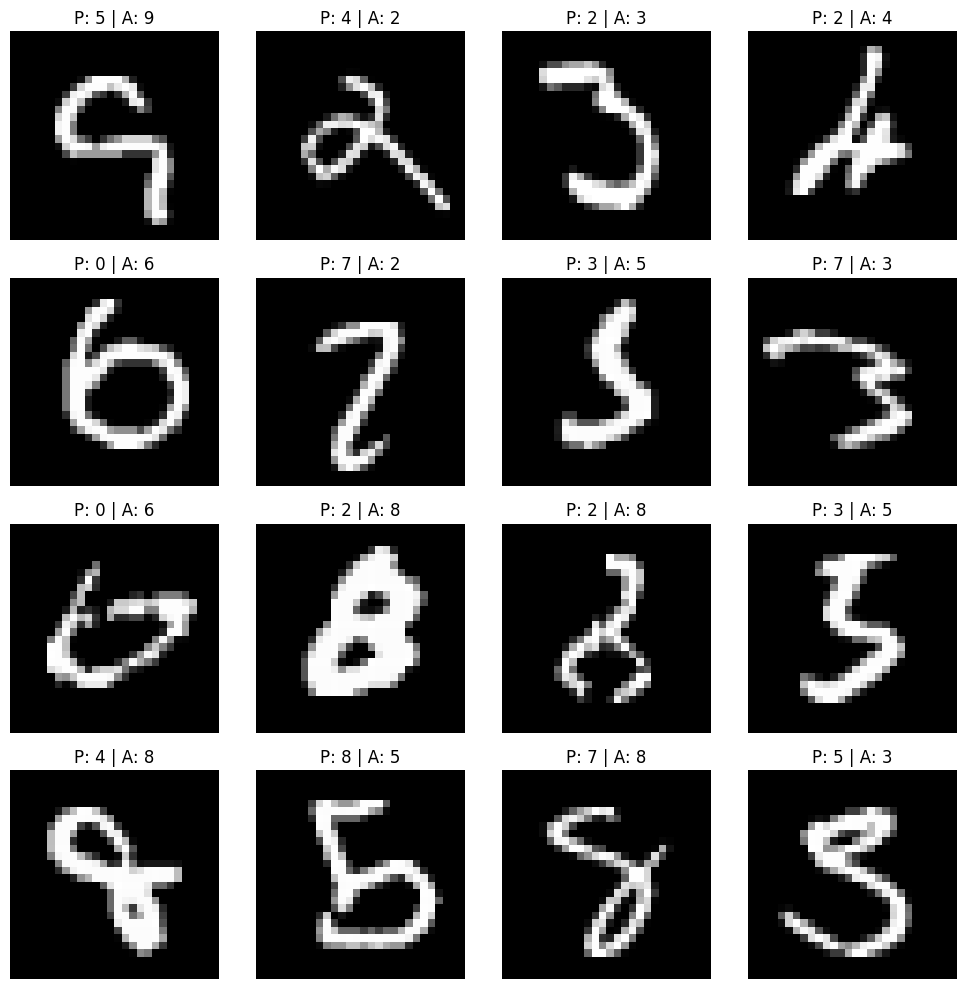

In [28]:
plt.figure(figsize=(10, 10))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(wrong_images[i].squeeze(), cmap="gray")

    plt.title(
        f"P: {wrong_predictions[i].item()} | A: {wrong_labels[i].item()}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [29]:
torch.save(model.state_dict(), "mnist_model.pth")

In [30]:
new_model = NeuralNetwork()

new_model.load_state_dict(torch.load("mnist_model.pth"))

<All keys matched successfully>

In [31]:
new_model.eval()

with torch.no_grad():
    
    outputs = new_model(images)

    predictions = torch.argmax(outputs, dim=1)

print(predictions[:10])

tensor([1, 2, 3, 4, 5, 6, 7, 8, 9, 0])
